In [1]:
try:
    import spherinator
except ImportError:
    %pip -q install git+https://github.com/HITS-AIN/Spherinator
    import spherinator
print(spherinator.__version__)

/home/doserbd/git/Tutorial-Spherinator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.5.1


In [2]:
from datasets import load_dataset

ds = load_dataset("HITS-AIN/IllustrisTNG_SKIRT_SDSS", split="train")

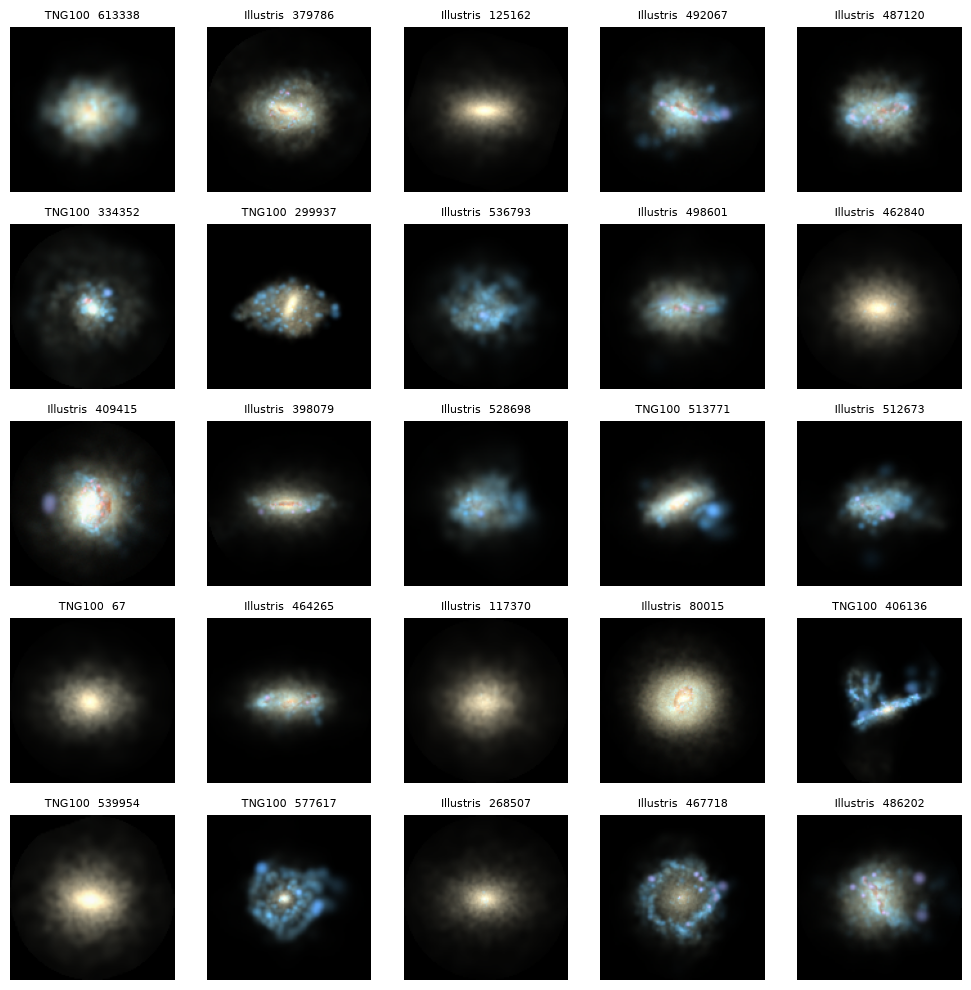

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, item in zip(axes.flat, ds.select(range(25))):
    ax.imshow(item["image"])
    ax.set_title(f"{item['simulation']}  {item['subhalo_id']}", fontsize=8)
    ax.axis("off")
fig.tight_layout()
plt.show()

In [ ]:
import spherinator
import torch

model = spherinator.models.VariationalAutoencoder(
    encoder=spherinator.models.HuggingFaceResNetEncoder(
        model_name="microsoft/resnet-18", output_dim=256
    ),
    decoder=spherinator.models.Sequential(
        modules=[
            torch.nn.Linear(in_features=257, out_features=256),
            spherinator.models.UpsamplingDecoder2D(
                input_dim=256, output_dim=[3, 128, 128], base_channels=512, seed_size=4
            ),
        ]
    ),
    reconstruction_loss=torch.nn.L1Loss(),
    z_dim=257,
    beta=1e-6,
    encoder_out_dim=256,
    max_scale=1e4,
)

_IncompleteInputError: incomplete input (1541696010.py, line 24)

In [ ]:
from lightning.pytorch import Trainer

trainer = Trainer(
    max_epochs=10,
    accelerator="auto",
    precision="16-mixed",
)
trainer.fit(model, datamodule=datamodule)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/doserbd/git/Tutorial-Spherinator/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


NameError: name 'model' is not defined